In [36]:
#!pip install langgraph

In [37]:
#!pip install langchain

In [38]:
#!pip install langchain_openai

In [19]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
import operator

In [5]:
from getpass import getpass
OPENAI_API_KEY=getpass("Enter OPENAI API key")

Enter OPENAI API key··········


In [6]:
import os
os.environ["OPENAI_API_KEY"]=OPENAI_API_KEY

In [8]:
model=ChatOpenAI(model="gpt-4o-mini")

In [9]:
# Need structured output that why need to create a class

In [10]:
class EvalutionSchema(BaseModel):
  feedback:str=Field(description="Detailed feedback for essay")
  score:int=Field(description="Score out of 10",ge=0,le=10)

In [11]:
structured_model=model.with_structured_output(EvalutionSchema)

In [13]:
essay="""
 Role of India in World’s Culture

India has played a significant role in shaping the culture of the world for thousands of years. Known for its rich traditions, diversity, spirituality, and knowledge, India has influenced many countries through religion, art, science, language, food, and philosophy. The cultural heritage of India is one of the oldest and most respected in human history.

One of India’s greatest contributions to world culture is spirituality and religion. Major religions such as Hinduism, Buddhism, Jainism, and Sikhism originated in India. Buddhism, founded by Gautama Buddha, spread from India to countries like China, Japan, Thailand, and Sri Lanka, influencing their traditions, values, and lifestyles. Indian philosophies such as yoga and meditation are now practiced worldwide for physical and mental well-being. Every year, millions of people across the globe celebrate the International Day of Yoga, showing India’s spiritual influence.

India has also made remarkable contributions in science and mathematics. Ancient Indian scholars introduced the concept of zero, the decimal system, and important developments in astronomy and medicine. These discoveries became the foundation for modern mathematics and science used across the world today. Indian texts like Ayurveda continue to inspire natural and holistic healing methods globally.

The cultural diversity of India is another reason for its global importance. India is home to many languages, traditions, dances, music styles, and festivals. Classical dance forms such as Bharatanatyam and Kathak, along with Indian classical music, are appreciated internationally. Festivals like Diwali and Holi are celebrated not only in India but also in many countries around the world. Indian cinema, especially Bollywood, has gained international popularity and entertains audiences across continents.

Indian cuisine is also famous worldwide. Dishes such as biryani, curry, dosa, and samosa are enjoyed by people in many countries. Indian spices and cooking styles have greatly influenced global food culture. Restaurants serving Indian food can be found in almost every major city in the world.

In modern times, India continues to contribute to global culture through technology, literature, education, and democracy. Indian writers, scientists, artists, and professionals are respected worldwide. India’s message of unity in diversity teaches the world how people from different backgrounds can live together peacefully.

In conclusion, India has played a vital role in enriching world culture through its spirituality, traditions, knowledge, arts, and values. Its influence can be seen in many aspects of daily life around the globe. India’s cultural legacy continues to inspire humanity and promote peace, wisdom, and harmony among nations.

"""

In [14]:
prompt=f"Evaluate the language quality of the following essay and provide the feedback and assign a score out of 10"

In [15]:
structured_model.invoke(prompt)

EvalutionSchema(feedback="The essay demonstrates a strong command of language, with varied sentence structures and a rich vocabulary. The ideas presented are articulated clearly and logically, allowing the reader to follow the author's line of reasoning effectively. However, there are a few instances of awkward phrasing and minor grammatical errors that disrupt the flow slightly. Transitions between paragraphs could be improved to enhance the cohesiveness of the piece. Overall, the essay presents a compelling argument, but with minor adjustments, it could reach a higher level of polish.", score=8)

In [16]:
# Now we have model which will provide the formatted output

In [17]:
# Now assign a state

In [23]:
class UPSCState(TypedDict):
  essay:str
  language_feedback:str
  analysis_feedback:str
  clarity_feedback:str
  overall_feedback:str
  individual_scores:Annotated[list[int],operator.add] # here using the  function 'add' because we are writing this variable in parallely and it should not override
  avg_scrore:float

In [24]:
# Now will add nodes

In [25]:
def evaluate_language(state:UPSCState)->UPSCState:
  prompt=f"Evaluate the language quality of the following essay and provide the feedback and assign a score out of 10 . essay ={state['essay']}"
  response=structured_model.invoke(prompt)
  return{'language_feedback':response.feedback,'individual_scores':[response.score]}


def evaluate_analysis(state:UPSCState)->UPSCState:
  prompt=f"Evaluate the depth of analysis the following essay and provide the feedback and assign a score out of 10 . essay ={state['essay']}"
  response=structured_model.invoke(prompt)
  return{'analysis_feedback':response.feedback,'individual_scores':[response.score]}


def evaluate_thought(state:UPSCState)->UPSCState:
  prompt=f"Evaluate the clarity of thought of the following essay and provide the feedback and assign a score out of 10 . essay ={state['essay']}"
  response=structured_model.invoke(prompt)
  return{'clarity_feedback':response.feedback,'individual_scores':[response.score]}


def final_evalution(state:UPSCState)->UPSCState:
  prompt=f"Based on the following feedback. Create a summarized feedback\n langauge feedback- {state['language_feedback']}\n analysis feedback- {state['analysis_feedback']}\n clarity feedback- {state['clarity_feedback']}"
  response=model.invoke(prompt).content # NOt using the structured model over here
  avg_score=sum(state['individual_scores'])/len(state['individual_scores'])
  return {'overall_feedback':response,'avg_score':avg_score}




In [27]:
graph=StateGraph(UPSCState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('final_evalution',final_evalution)


In [28]:
# Adding edges

In [29]:
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_thought')


In [30]:
graph.add_edge('evaluate_language','final_evalution')
graph.add_edge('evaluate_analysis','final_evalution')
graph.add_edge('evaluate_thought','final_evalution')

In [31]:
graph.add_edge('final_evalution',END)

In [32]:
workflow=graph.compile()

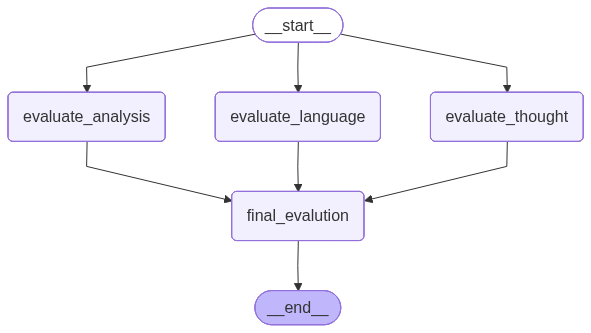

In [33]:
workflow

In [34]:
initial_state={
    "essay":essay
}

In [35]:
workflow.invoke(initial_state)

{'essay': '\n Role of India in World’s Culture\n\nIndia has played a significant role in shaping the culture of the world for thousands of years. Known for its rich traditions, diversity, spirituality, and knowledge, India has influenced many countries through religion, art, science, language, food, and philosophy. The cultural heritage of India is one of the oldest and most respected in human history.\n\nOne of India’s greatest contributions to world culture is spirituality and religion. Major religions such as Hinduism, Buddhism, Jainism, and Sikhism originated in India. Buddhism, founded by Gautama Buddha, spread from India to countries like China, Japan, Thailand, and Sri Lanka, influencing their traditions, values, and lifestyles. Indian philosophies such as yoga and meditation are now practiced worldwide for physical and mental well-being. Every year, millions of people across the globe celebrate the International Day of Yoga, showing India’s spiritual influence.\n\nIndia has als